# Large-Scale Thematic Research Workflow 

This notebook builds **auditable signals** from unstructured content across a broad equity universe.

It supports two signal families with an explicit **accuracy/recall trade-off**:

1. **Basic signal (high recall, lower precision, fast):**
   - constructed directly from retrieval outputs using `score = sum(relevance × sentiment)` and `volume`.
2. **Advanced signal (higher accuracy/precision, slower):**
   - adds LLM validation (`is_theme_related`, `impact`) before rolling signal construction.

## What this workflow is for
- Systematic hypothesis testing on thematic exposures.
- Cross-sectional ranking and long/short research.
- Feature generation for downstream models.

## Methodological guardrails
- Universe-constrained entity resolution.
- Chunk-level deduplication.
- Explicit timestamp handling and NYSE trading-date alignment (`date_nyse_1530`) to reduce leakage risk.

Use this notebook as a research pipeline template, not as evidence of production-ready alpha.


**Create a `.env` file in this folder before running the notebook**

Required:

`BIGDATA_API_KEY=your_api_key`

Optional:

- `BIGDATA_API_BASE_URL=...` (override API endpoint)
- `OPENAI_API_KEY=...` (needed for LLM validation stage)

Notes:
- Restart the kernel after changing credentials.
- Keep credentials out of source control.


In [36]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Imports


In [37]:
import asyncio
import json
import logging
import os
import pickle
import sys
from pathlib import Path
from zoneinfo import ZoneInfo

import nest_asyncio
import pandas as pd
import plotly.io as pio
from dotenv import load_dotenv

from src import (
    BigDataSession,
    convert_to_dataframe,
    deduplicate_documents,
    execute_search,
    execute_full_grid_search,
    explode_to_dataframe,
    load_plan,
    plan_search,
    save_plan,
    aggregate_results_by_chunk,
    extract_companies_from_entity_list,
    get_unknown_entities_from_df_column,
    keep_only_companies_in_detections,
    map_create_only_companies_column,
)

import importlib
import src.helper as helper_mod

importlib.reload(helper_mod)
build_rolling_impact_signal = helper_mod.build_rolling_impact_signal
plot_top_entities_rolling_signal = helper_mod.plot_top_entities_rolling_signal
mask_companies_in_df = helper_mod.mask_companies_in_df

from src.labeler.screener_labeler import Labeler, merge_validation_labels

from src.mindmap import generate_risk_tree, generate_theme_tree


## Configuration


In [38]:
# Suppress verbose HTTP logging
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# Load environment variables
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

# Apply nest_asyncio if needed (for Jupyter environments)
try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except RuntimeError:
    pass  # No running loop, nest_asyncio not needed

# Configure Plotly renderer
try:
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
    else:
        pio.renderers.default = 'plotly_mimetype+notebook'
except Exception:
    pio.renderers.default = 'notebook'



✅ nest_asyncio applied


## Setup & Authentication

This section loads environment credentials from `.env` and initializes `session`.

Expected outcomes:
- authenticated Bigdata session,
- stable API base URL,
- optional OpenAI key availability for advanced (LLM-verified) signal path.


In [39]:
# Setup & Authentication (single source of truth)
# Loads credentials from .env in the notebook folder.
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

BIGDATA_API_KEY = os.getenv("BIGDATA_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

try:
    session = BigDataSession()
    print("✅ API key configured")
    print(f"✅ API Base URL: {session.api_base_url}")
except ValueError as e:
    print(f"❌ Authentication failed: {e}")
    print("   Please set BIGDATA_API_KEY in your .env file")
    session = None


✅ API key configured
✅ API Base URL: https://api.bigdata.com


## Search Parameters

Define the core experiment scope:
- thematic hypothesis,
- investable universe,
- analysis window,
- retrieval sampling controls.

These settings directly affect recall, compute cost, and downstream signal stability.


In [40]:
# Main theme to analyze - will be decomposed into sub-themes for higher recall
theme = "Semiconductor supply shortage disrupted global production"

# Universe: CSV file with columns 'id' (entity ID) and 'name' (company name)
universe_csv = "id_name_mapping_us_top_3000.csv"

# Time window for the search
start_date = "2021-01-01"
end_date = "2021-06-30"

# Sampling percentage: controls the % of chunks to retrieve per basket (0.0-1.0)
# Lower values = faster execution, higher values = more comprehensive results
chunk_percentage = 1


## 1. Theme Decomposition

A single query under-covers real-world language variation. We decompose the main theme into terminal sub-themes to improve retrieval coverage.

Why this matters:
- higher recall across different phrasing of the same economic mechanism,
- better separation of causal channels (e.g., delays, margin pressure, cancellations).

Output artifact:
- `terminal_labels_and_summaries` used as independent search queries.


In [41]:
# Generate risk tree from main theme using LLM
# Alternative: use generate_theme_tree(main_theme=theme) for general thematic decomposition
risk_tree = generate_risk_tree(
    main_theme=theme
)

# Extract terminal nodes: these are the specific sub-themes we'll search for
terminal_labels_and_summaries = risk_tree.get_terminal_label_summaries()



In [42]:
terminal_labels_and_summaries


{'Production Delays': 'Companies face production delays due to semiconductor supply shortages disrupting global production.',
 'Increased Lead Times': 'Firms experience increased lead times for products reliant on semiconductor components.',
 'Supplier Instability': 'Supplier instability arises as firms struggle to secure semiconductor supplies globally.',
 'Rising Input Costs': 'Rising input costs occur as semiconductor shortages drive up prices for components.',
 'Increased Operational Costs': 'Increased operational costs result from firms needing to expedite semiconductor shipments.',
 'Higher R&D Expenses': 'Higher R&D expenses arise as companies invest in alternative technologies due to shortages.',
 'Loss of Market Share': 'Companies may lose market share as competitors secure semiconductor supplies first.',
 'Reduced Product Offerings': 'Reduced product offerings occur as firms cannot produce enough goods due to shortages.',
 'Geographic Market Limitations': 'Geographic market l

In [43]:
# For faster testing, only use the first item from terminal_labels_and_summaries
terminal_labels_and_summaries = {'Production Delays':'Companies will face production delays due to semiconductor supply shortages disrupting global production.'}

## 2. Search Planning with Smart Batching

`plan_search(...)` builds a query plan that allocates retrieval budget across entities/time based on expected content density.

Why this matters:
- avoids over-allocating budget to only high-media names,
- improves cross-sectional fairness and coverage,
- controls query count and execution feasibility.

Key planning levers:
- `volume_query_mode`, `volume_correction`, `source_ids`, `min_period_days`.

Output artifact:
- basketized search plans with expected chunk counts and query metadata.


In [44]:
# Create search plans for each sub-theme
plans_list = []
for i, summary in enumerate(terminal_labels_and_summaries.values()):
    plan = plan_search(
        text=summary,
        universe_csv_path=universe_csv,
        start_date=start_date,
        end_date=end_date,
        session=session,
        volume_query_mode="iterative",
        volume_correction=(0.7, 500),
        max_iterations_per_batch=10,
        reranker_enabled=True,
        reranker_threshold=0.3, 
        min_period_days=30,  # Minimum time window size for each basket
    )

    
    # Save plan to file for reproducibility and debugging
    plan_file = f"search_plan_node_{i}.json"
    plans_list.append(plan_file)
    save_plan(plan, plan_file)

    print(f"Theme {i}: {list(terminal_labels_and_summaries.keys())[i]}")
    print(f"  Total expected chunks: {plan['total_expected_chunks']:,}")
    print(f"  Number of baskets: {len(plan['baskets'])}")



2026-02-20 17:13:25,906 - INFO - Planning search for text: 'Companies will face production delays due to semiconductor supply shortages disrupting global production.'
2026-02-20 17:13:25,906 - INFO - Date range: 2021-01-01 to 2021-06-30
2026-02-20 17:13:25,910 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
2026-02-20 17:13:25,910 - INFO - Loaded 4731 companies from universe
2026-02-20 17:13:25,911 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting
PHASE 1: Querying full period for all companies (2021-01-01 to 2021-06-30)
         Mode: iterative
    [ITERATIVE MODE] Querying 4731 companies in 10 batches of 500
    Each batch iterates until no new companies are found (max 10 iterations)
      Batch 1/10, Iter 1: Found 98 new companies, 402 remaining
      Batch 1/10, Iter 2: Found 156 new companies, 246 remaining
      Batch 1/10, Iter 3: Found 146 new companies, 100 remaining
      Batch 1/10, Iter 4: Found 38 new companies, 62 remaining
     

## 3. Search Execution

Execute planned baskets and collect raw documents/chunks.

Why this matters:
- converts planning assumptions into realized retrieval coverage,
- creates the base evidence set for both signal families.

Output artifact:
- `results_list` (deduplicated retrieval outputs per sub-theme).


In [45]:
# Execute searches for all sub-themes
results_list = []
for plan_name in plans_list:
    plan = load_plan(plan_name)
    
    results_raw = execute_search(
        search_plan=plan,
        chunk_percentage=chunk_percentage,  # Sample this percentage of estimated chunks
        requests_per_minute=450,  # API rate limit
        max_workers=10,
        session=session,
    )

    # Deduplicate: merge chunks from same document across different baskets
    results = deduplicate_documents(results_raw)
    
    # Save raw results for debugging/reproducibility
    with open(f'results_{plan_name}', 'w') as f:
        json.dump(results, f)
    results_list.append(results)

    print(f"\n Search complete for {plan_name}!")
    print(f"   Retrieved {len(results):,} deduplicated documents")



2026-02-20 17:16:03,355 - INFO - Plan loaded from search_plan_node_0.json
2026-02-20 17:16:03,356 - INFO - Executing search with 100.0% of chunks
2026-02-20 17:16:03,356 - INFO - Total maximum expected chunks: 254,600
2026-02-20 17:16:03,357 - INFO - Searching 288 baskets
2026-02-20 17:16:04,989 - INFO - Basket high_basket_0: Retrieved 49 documents with 51 chunks
2026-02-20 17:16:05,562 - INFO - Basket high_basket_3: Retrieved 4 documents with 5 chunks
2026-02-20 17:16:05,757 - INFO - Basket high_basket_1: Retrieved 1 documents with 1 chunks
2026-02-20 17:16:06,089 - INFO - Basket high_basket_9: Retrieved 21 documents with 21 chunks
2026-02-20 17:16:06,105 - INFO - Basket high_basket_2: Retrieved 44 documents with 45 chunks
2026-02-20 17:16:06,670 - INFO - Basket high_basket_11: Retrieved 6 documents with 6 chunks
2026-02-20 17:16:06,993 - INFO - Basket high_basket_5: Retrieved 131 documents with 167 chunks
2026-02-20 17:16:07,118 - INFO - Basket high_basket_14: Retrieved 16 documents 

## 3.1 Standard Full-Grid Search (Baseline)

Optional baseline path without smart batching.

Use this for:
- diagnostics,
- sanity checks,
- cost/coverage comparison against smart batching.

In large universes, this path is typically much less query-efficient.


In [46]:
# Standard Full Grid Search

#fg_search_batch_size = 500  # number of companies per API request (API maximum)
#fg_search_max_chunks_per_request = 1000  # max chunks per query (API limit)
#fg_search_requests_per_minute = 50

#results_list = []
#for i, summary in enumerate(terminal_labels_and_summaries.values()):
#    results_raw = execute_full_grid_search(
#        text=summary,
#        universe_csv_path=universe_csv,
#        start_date=start_date,
#        end_date=end_date,
#        batch_size=fg_search_batch_size,
#        session=session,
#        requests_per_minute=fg_search_requests_per_minute,
#        max_chunks_per_request=fg_search_max_chunks_per_request,
#    )

    # Deduplicate: merge chunks from same document across different batches
#    results = deduplicate_documents(results_raw)

#    results_list.append(results)
#    label = list(terminal_labels_and_summaries.keys())[i]
#    print(f"\n Normal search complete for theme {i}: {label}")
#    print(f"   Retrieved {len(results):,} deduplicated documents")




## 4. Results Aggregation and Labeling

Merge outputs from all sub-theme searches and deduplicate at chunk level.

Why this matters:
- preserves recall from multi-query retrieval,
- avoids double-counting repeated chunk evidence,
- keeps thematic provenance (`label`, `theme`) for auditability.

Output artifact:
- unified chunk-level dataset for entity mapping and signal construction.


In [47]:
# Convert results to DataFrames and tag with sub-theme labels
df_results_list = []
labels_summaries = list(terminal_labels_and_summaries.items())

for results, (label, theme_text) in zip(results_list, labels_summaries):
    df_exploded_by_chunk = convert_to_dataframe(results)
    df_exploded_by_chunk['label'] = label
    df_exploded_by_chunk['theme'] = theme_text
    df_results_list.append(df_exploded_by_chunk)

# Concatenate all results
df_concat = pd.concat(df_results_list, ignore_index=True)

# Aggregate by chunk (chunk_text): same chunk from different themes gets label/theme as lists
df_exploded_by_chunk = aggregate_results_by_chunk(df_concat)

print(f"Total unique chunks: {len(df_exploded_by_chunk):,}")

Total unique chunks: 6,215


In [48]:
# Save checkpoint (uncomment to save - useful for long-running workflows)
# with open('df_exploded_by_chunk.pkl', 'wb') as f:
#     pickle.dump(df_exploded_by_chunk, f)

# Load from checkpoint (uncomment to skip search if already completed)
# with open('df_exploded_by_chunk.pkl', 'rb') as f:
#     df_exploded_by_chunk = pickle.load(f)


## 5. Entity Resolution and Company Filtering

Map text evidence to canonical entities and restrict to the investable universe.

Why this matters:
- makes outputs portfolio-compatible,
- removes orphan/non-investable detections,
- stabilizes cross-sectional comparability.

Output artifact:
- `df_exploded_by_entity` with one row per `(chunk, entity)` in-universe mapping.


In [49]:
# Resolve unknown entities and filter to companies only
# This makes API calls to the Knowledge Graph to identify which entities are companies
entities = get_unknown_entities_from_df_column(
    df_exploded_by_chunk, 
    "entity_ids", 
    universe_csv
)

# Query API to get company information for unknown entities
other_companies = extract_companies_from_entity_list(entities, session)

# Create column with only company entity IDs
df_exploded_by_chunk_only_companies = map_create_only_companies_column(
    df_exploded_by_chunk, 
    universe_csv, 
    other_companies
)

# Filter detections to keep only companies
df_detection = keep_only_companies_in_detections(df_exploded_by_chunk_only_companies)

Processing batches...: 100%|██████████| 49/49 [00:32<00:00,  1.49it/s]


### 5.1 Explode by Entity

Transform chunk-level results into `(chunk, entity)` observations.

Each row becomes an exposure candidate with:
- timestamp metadata,
- relevance/sentiment fields,
- entity identity required for cross-sectional aggregation.


In [50]:
# Explode: one row per (chunk, entity) pair, filtered by universe
df_exploded_by_entity = explode_to_dataframe(
    df_detection,
    universe_csv=universe_csv
)

print(f"Exploded DataFrame shape: {df_exploded_by_entity.shape}")
print(f"Unique entities: {df_exploded_by_entity['entity_id'].nunique()}")
df_exploded_by_entity.head()

Exploded DataFrame shape: (9654, 21)
Unique entities: 856


,entity_name,entity_id,chunk_text,label,theme,date,doc_timestamp,doc_id,headline,source_id,...,source_rank,chunk_index,chunk_relevance,chunk_sentiment,entity_ids,detections,url,reporting_entities,entity_ids_companies,companies_detection
0,Humana Inc.,00067A,Former VMWare CEO Pat Gelsinger took over the ...,[Production Delays],[Companies will face production delays due to ...,2021-04-28,2021-04-28 13:25:22+00:00,72EC508F09E5F0351DFF161607A1EE82,Silicon Valley's dominance in advertising is o...,2435A4,...,RANK_1,10,0.529826,-0.61,"[EB2E30, EB2E30, CC71F7, 8E02D0, 17EDA5, 17EDA...","[{'id': 'EB2E30', 'start': 587, 'end': 606, 't...",https://edition.cnn.com/2021/04/28/investing/p...,[],"[17EDA5, 17EDA5, D21EF3, 00067A, B4C673, 1476C...","[{'id': '17EDA5', 'start': 57, 'end': 69, 'typ..."
1,Bilibili Inc.,01316B,"ITM Semiconductor\n1,350\nAsian Stars Fund Pur...",[Production Delays],[Companies will face production delays due to ...,2021-06-30,2021-06-30 00:00:00+00:00,2460BFAB8EDF350C79D4499751A88D25,Polar Capital Holdings announces Interim Finan...,02821E,...,RANK_1,871,0.041951,-0.09,"[61DE17, B811D5, B811D5, A9C322, 9E4E2A, 01316...","[{'id': '61DE17', 'start': 965, 'end': 979, 't...",https://files.captide.co/original-docs/4198230...,[],"[61DE17, B811D5, B811D5, A9C322, 01316B, 01316...","[{'id': '61DE17', 'start': 965, 'end': 979, 't..."
2,Fujifilm Holdings Corp.,01329F,"With this expansion, Avantor has nine innovati...",[Production Delays],[Companies will face production delays due to ...,2021-04-22,2021-04-22 14:59:26+00:00,208DCB1621E9499E63BA3D3F2AE2E34A,"Global Cell Therapy Market By Therapy Type, By...",5A5702,...,RANK_1,15,0.045898,0.43,"[893E0B, BDE856, 1E48BF, 6A3F48, 941990, B6F7F...","[{'id': '893E0B', 'start': 200, 'end': 208, 't...",,[],"[B6F7F7, B6F7F7, 01329F, 01329F]","[{'id': 'B6F7F7', 'start': 21, 'end': 28, 'typ..."
3,Fujifilm Holdings Corp.,01329F,The break-up of the primaries is as follows: \...,[Production Delays],[Companies will face production delays due to ...,2021-05-26,2021-05-26 16:19:46+00:00,1A11F05C9BEACB49D9BA3D375D94E658,The Stem Cell Manufacturing market is projecte...,5A5702,...,RANK_1,3,0.062471,-0.02,"[8665BA, 21A94B, C6A466, A0145E, 5EF3A1, 915FA...","[{'id': '8665BA', 'start': 359, 'end': 383, 't...",,[],"[8665BA, 21A94B, 5EF3A1, 915FA7, 25YG9K, E1E09...","[{'id': '8665BA', 'start': 359, 'end': 383, 't..."
4,PepsiCo Inc.,013528,4.0 Supply Chain Ecosystem Company Analysis \n...,[Production Delays],[Companies will face production delays due to ...,2021-03-22,2021-03-22 09:38:31+00:00,4A08C716513D0F3CE469994B647A8A84,Insights on the Artificial Intelligence in Sup...,5A5702,...,RANK_1,13,0.062082,0.03,"[SXAJ2H, 75058F, 46E936, 031025, D7A681, 20999...","[{'id': 'SXAJ2H', 'start': 612, 'end': 634, 't...",,[],"[SXAJ2H, 031025, D7A681, 4AC91D, ACDF88, EB696...","[{'id': 'SXAJ2H', 'start': 612, 'end': 634, 't..."


### 5.2 Basic Signal Construction (High Recall, Fast)

This section builds the **basic signal family** directly from retrieval outputs.

Definition per entity-day:
- `score = Σ(relevance × sentiment)` over deduplicated `(entity, doc, chunk)` rows
- `volume = count(entity, doc, chunk)`

Interpretation:
- high recall, low-latency thematic proxy,
- lower precision than LLM-verified path,
- useful for broad hypothesis screening and rapid iteration.


In [51]:
# Build daily basic entity-level signals from deduplicated chunk rows

relevance_col = "chunk_relevance" if "chunk_relevance" in df_exploded_by_entity.columns else "relevance"
sentiment_col = "chunk_sentiment" if "chunk_sentiment" in df_exploded_by_entity.columns else "sentiment"
chunk_col = "chunk_index" if "chunk_index" in df_exploded_by_entity.columns else "chunk_cnum"
date_col = "doc_timestamp" if "doc_timestamp" in df_exploded_by_entity.columns else "date"

required_cols = {"entity_id", "doc_id", chunk_col, relevance_col, sentiment_col, date_col}
missing_cols = [c for c in required_cols if c not in df_exploded_by_entity.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for daily basic signals: {missing_cols}")

# 1) Keep rows with valid relevance/sentiment and parse date
basic_long = df_exploded_by_entity[
    ["entity_id", "doc_id", chunk_col, date_col, relevance_col, sentiment_col]
].copy()
basic_long = basic_long.dropna(subset=[relevance_col, sentiment_col, date_col])

# Assign trading date so we aggregate before 15:30 NY (no look-ahead for close-to-close NYSE).
# Assume source timestamps are UTC; convert to Eastern then offset so 15:30 NY = day boundary.
eastern = ZoneInfo("America/New_York")
dt_utc = pd.to_datetime(basic_long[date_col], errors="coerce", utc=True)
dt_ny = dt_utc.dt.tz_convert(eastern)
# Trading date T = [15:30 NY on T-1, 15:30 NY on T). Add 8.5h so 15:30 becomes midnight.
basic_long["date"] = (dt_ny + pd.Timedelta(hours=8.5)).dt.date
basic_long = basic_long.dropna(subset=["date"])

# 2) Deduplicate per entity-date-doc-chunk
basic_long = basic_long.drop_duplicates(subset=["entity_id", "date", "doc_id", chunk_col])

# 3) Aggregate by entity and date
if basic_long.empty:
    df_basic_signals = pd.DataFrame(columns=["rp_entity_id", "date", "score", "volume", "entity_name"])
else:
    basic_long["score_component"] = basic_long[relevance_col] * basic_long[sentiment_col]

    entity_daily_agg = (
        basic_long.groupby(["entity_id", "date"], as_index=False)
        .agg(
            score=("score_component", "sum"),
            volume=("entity_id", "size"),
        )
        .rename(columns={"entity_id": "rp_entity_id"})
    )

    # Enrich with entity names from the selected universe CSV
    df_universe = pd.read_csv(universe_csv)
    df_universe = df_universe.rename(columns={"id": "rp_entity_id", "name": "entity_name"})

    df_basic_signals = entity_daily_agg.merge(
        df_universe[["rp_entity_id", "entity_name"]],
        on="rp_entity_id",
        how="left",
    )

    df_basic_signals = df_basic_signals[["rp_entity_id", "date", "score", "volume", "entity_name"]]
    df_basic_signals = df_basic_signals.sort_values(["rp_entity_id", "date"]).reset_index(drop=True)

# Save
basic_signals_path = "df_basic_signals_daily.csv"
df_basic_signals.to_csv(basic_signals_path, index=False)

print(f"Deduplicated entity-date-doc-chunk rows: {len(basic_long)}")
print(f"Entity-date rows with basic signals: {len(df_basic_signals)}")
print(f"Saved: {basic_signals_path}")
df_basic_signals.head()


Deduplicated entity-date-doc-chunk rows: 9654
Entity-date rows with basic signals: 4265
Saved: df_basic_signals_daily.csv


,rp_entity_id,date,score,volume,entity_name
0,00067A,2021-04-28,-0.323194,1,Humana Inc.
1,01316B,2021-06-30,-0.003776,1,Bilibili Inc.
2,01329F,2021-04-22,0.019736,1,Fujifilm Holdings Corp.
3,01329F,2021-05-26,-0.001249,1,Fujifilm Holdings Corp.
4,013528,2021-03-22,0.001862,1,PepsiCo Inc.


## 6. Company Masking (Optional, Recommended for LLM Step)

Before LLM validation, company names are masked to reduce model prior bias toward famous names.

Why this matters:
- improves label consistency,
- reduces reputation-driven false positives/negatives,
- supports cleaner advanced-signal quality control.


In [52]:
# Mask company names to avoid LLM bias
df_masked = mask_companies_in_df(df_exploded_by_entity)
print(f"Masked DataFrame shape: {df_masked.shape}")

Masked DataFrame shape: (9654, 23)


## 7. LLM Validation: Advanced Signal Input (Higher Accuracy)

This stage builds the **advanced signal family** by adding model-based verification:
- `is_theme_related` (relevance gate)
- `impact` (directional effect label)

Accuracy/recall trade-off vs basic signal:
- **Basic:** higher recall, lower precision.
- **Advanced (LLM-verified):** higher accuracy/precision, lower recall, higher cost/latency.

Output artifact:
- `df_with_labels`, used to build rolling impact signals.


In [53]:
# Initialize labeler with LLM configuration
labeler = Labeler(llm_model_config="openai::gpt-4o-mini")


# Run LLM validation in parallel
labels_df = labeler.get_validation_labels(
    main_theme=theme,
    df_masked=df_masked,
    timeout=20,
    max_workers=55,  # Parallel LLM calls
)

# Merge labels back to original DataFrame
df_with_labels = merge_validation_labels(df_masked, labels_df)

print(f"Labeled DataFrame shape: {df_with_labels.shape}")
print(f"Theme-related chunks: {df_with_labels['is_theme_related'].sum():,}")
df_with_labels.head()

2026-02-20 17:17:31,980 - INFO - Running 9654 prompts concurrently


Querying an LLM...: 100%|██████████| 9654/9654 [05:03<00:00, 31.80it/s]

Labeled DataFrame shape: (9654, 26)
Theme-related chunks: 5,839


,entity_name,entity_id,chunk_text,label,theme,date,doc_timestamp,doc_id,headline,source_id,...,detections,url,reporting_entities,entity_ids_companies,companies_detection,masked_text,other_entities_map,is_theme_related,impact,motivation
0,Humana Inc.,00067A,Former VMWare CEO Pat Gelsinger took over the ...,[Production Delays],[Companies will face production delays due to ...,2021-04-28,2021-04-28 13:25:22+00:00,72EC508F09E5F0351DFF161607A1EE82,Silicon Valley's dominance in advertising is o...,2435A4,...,"[{'id': 'EB2E30', 'start': 587, 'end': 606, 't...",https://edition.cnn.com/2021/04/28/investing/p...,[],"[17EDA5, 17EDA5, D21EF3, 00067A, B4C673, 1476C...","[{'id': '17EDA5', 'start': 57, 'end': 69, 'typ...",Former Other_Company_7 CEO Pat Gelsinger took ...,"[(1, B4C673), (2, 86170D), (3, 1476C1), (4, D2...",False,Unclear,"Target Company is not mentioned in the text, a..."
1,Bilibili Inc.,01316B,"ITM Semiconductor\n1,350\nAsian Stars Fund Pur...",[Production Delays],[Companies will face production delays due to ...,2021-06-30,2021-06-30 00:00:00+00:00,2460BFAB8EDF350C79D4499751A88D25,Polar Capital Holdings announces Interim Finan...,02821E,...,"[{'id': '61DE17', 'start': 965, 'end': 979, 't...",https://files.captide.co/original-docs/4198230...,[],"[61DE17, B811D5, B811D5, A9C322, 01316B, 01316...","[{'id': '61DE17', 'start': 965, 'end': 979, 't...","ITM Semiconductor\n1,350\nAsian Stars Fund Pur...","[(1, 8002F0), (2, DSG92U), (3, 94B448), (4, 9D...",False,Unclear,Target Company is mentioned in a list of other...
2,Fujifilm Holdings Corp.,01329F,"With this expansion, Avantor has nine innovati...",[Production Delays],[Companies will face production delays due to ...,2021-04-22,2021-04-22 14:59:26+00:00,208DCB1621E9499E63BA3D3F2AE2E34A,"Global Cell Therapy Market By Therapy Type, By...",5A5702,...,"[{'id': '893E0B', 'start': 200, 'end': 208, 't...",,[],"[B6F7F7, B6F7F7, 01329F, 01329F]","[{'id': 'B6F7F7', 'start': 21, 'end': 28, 'typ...","With this expansion, Other_Company_1 has nine ...","[(1, B6F7F7)]",False,Unclear,Target Company is not mentioned in relation to...
3,Fujifilm Holdings Corp.,01329F,The break-up of the primaries is as follows: \...,[Production Delays],[Companies will face production delays due to ...,2021-05-26,2021-05-26 16:19:46+00:00,1A11F05C9BEACB49D9BA3D375D94E658,The Stem Cell Manufacturing market is projecte...,5A5702,...,"[{'id': '8665BA', 'start': 359, 'end': 383, 't...",,[],"[8665BA, 21A94B, 5EF3A1, 915FA7, 25YG9K, E1E09...","[{'id': '8665BA', 'start': 359, 'end': 383, 't...",The break-up of the primaries is as follows: \...,"[(1, 25YG9K), (2, 915FA7), (3, 59560C), (4, 99...",False,Unclear,Target Company is mentioned in the context of ...
4,PepsiCo Inc.,013528,4.0 Supply Chain Ecosystem Company Analysis \n...,[Production Delays],[Companies will face production delays due to ...,2021-03-22,2021-03-22 09:38:31+00:00,4A08C716513D0F3CE469994B647A8A84,Insights on the Artificial Intelligence in Sup...,5A5702,...,"[{'id': 'SXAJ2H', 'start': 612, 'end': 634, 't...",,[],"[SXAJ2H, 031025, D7A681, 4AC91D, ACDF88, EB696...","[{'id': 'SXAJ2H', 'start': 612, 'end': 634, 't...",4.0 Supply Chain Ecosystem Company Analysis \n...,"[(1, 373E85), (2, 713810), (3, 3CBA2A), (4, 87...",False,Unclear,"Target Company is mentioned, but the text does..."


In [54]:
# Normalize event timestamps to NYSE-aligned trading date (cutoff 15:30 New York)
# This makes timing explicit before rolling signal construction.

ts_col = "doc_timestamp" if "doc_timestamp" in df_with_labels.columns else "date"

dt_utc = pd.to_datetime(df_with_labels[ts_col], errors="coerce", utc=True)
dt_ny = dt_utc.dt.tz_convert(ZoneInfo("America/New_York"))

# Trading date T = [15:30 NY on T-1, 15:30 NY on T)
df_with_labels["date_nyse_1530"] = (dt_ny + pd.Timedelta(hours=8.5)).dt.date

print(f"Using timestamp column: {ts_col}")
print(f"Rows with valid NYSE trading date: {df_with_labels['date_nyse_1530'].notna().sum():,} / {len(df_with_labels):,}")
df_with_labels[[ts_col, "date_nyse_1530"]].tail(10)

Using timestamp column: doc_timestamp
Rows with valid NYSE trading date: 9,654 / 9,654


,doc_timestamp,date_nyse_1530
9644,2021-06-23 05:42:55+00:00,2021-06-23
9645,2021-06-23 05:43:29+00:00,2021-06-23
9646,2021-06-23 00:00:00+00:00,2021-06-23
9647,2021-06-23 05:43:29+00:00,2021-06-23
9648,2021-06-23 04:51:00+00:00,2021-06-23
9649,2021-06-23 03:02:37+00:00,2021-06-23
9650,2021-06-28 11:21:30+00:00,2021-06-28
9651,2021-06-28 11:21:30+00:00,2021-06-28
9652,2021-06-28 11:21:30+00:00,2021-06-28
9653,2021-06-28 11:21:30+00:00,2021-06-28


In [55]:
# Save checkpoint (uncomment to save)
# with open('df_with_labels.pkl', 'wb') as f:
#    pickle.dump(df_with_labels, f)
# Load from checkpoint (uncomment to skip LLM validation if already completed)
# with open('df_with_labels.pkl', 'rb') as f:
#     df_with_labels = pickle.load(f)

## 8. Rolling Impact Signal Construction (Advanced Signal)

Convert validated labels into entity-level daily/rolling time series.

Important timing integrity note:
- before this step, events are normalized to `date_nyse_1530`
  (NYSE-aligned trading date snap) to reduce look-ahead leakage.

Signal semantics:
- rolling net impact (`sum` or `mean`) over 7d/30d windows,
- optional calendar expansion for continuous daily panels.

Output artifact:
- `df_rolling_signal` for ranking, visualization, and backtesting.


In [56]:
# Build rolling impact signal from LLM labels
df_rolling_signal = build_rolling_impact_signal(
    df_with_labels,
    entity_col="entity_name",
    date_col="date_nyse_1530",
    impact_col="impact",
    is_theme_related_col="is_theme_related",
    window_7d=7,
    window_30d=30,
    rolling_agg="sum",  # "mean" = media rolling, "sum" = somma rolling
    expand_calendar_days=True,
)
df_rolling_signal

,date_nyse_1530,entity_name,daily_score,n_positive,n_negative,n_neutral,n_unclear,volume,signal_7d,signal_30d,volume_7d,volume_30d
0,2021-05-11,3D Systems Corp.,-1.0,0.0,2.0,0.0,0.0,2.0,-1.0,-1.0,2.0,2.0
1,2021-02-17,3M Co.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0
2,2021-02-18,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,1.0,1.0
3,2021-02-19,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,1.0,1.0
4,2021-02-20,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14771,2021-05-31,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,2.0
14772,2021-06-01,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,2.0
14773,2021-06-02,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,2.0
14774,2021-06-08,iRobot Corp.,-1.0,0.0,3.0,0.0,0.0,3.0,-1.0,-1.0,3.0,3.0


### 8.1 Visualize Top Companies by Volume

Plot rolling signal trajectories for the most text-exposed names.

Use this for:
- regime/context interpretation,
- outlier detection,
- qualitative sanity checks before portfolio tests.


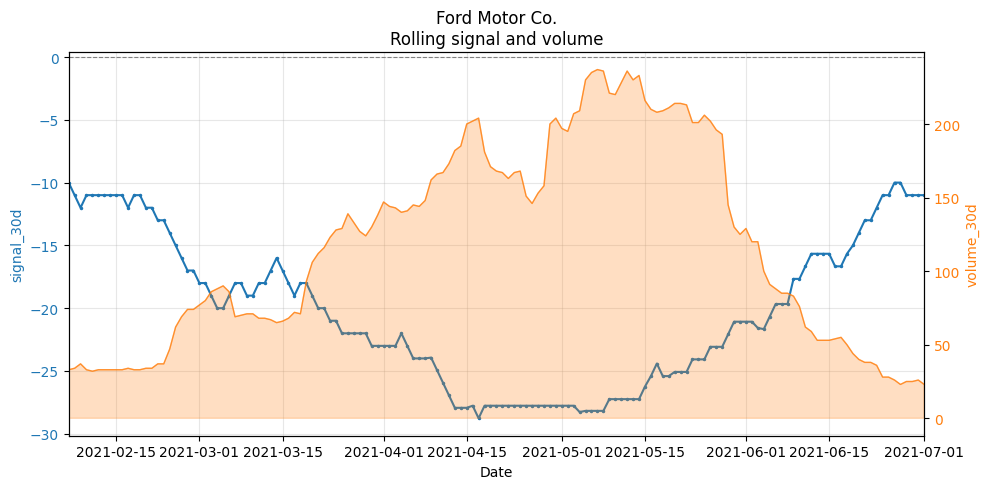

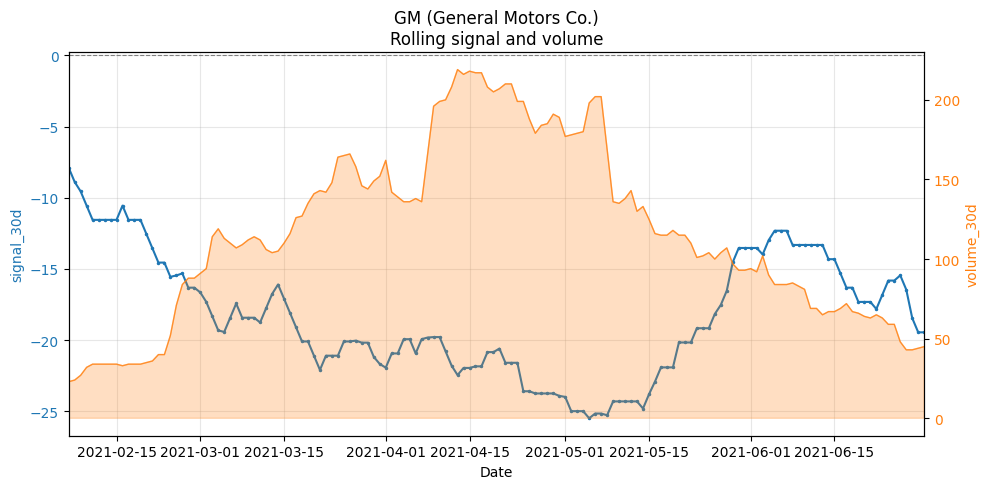

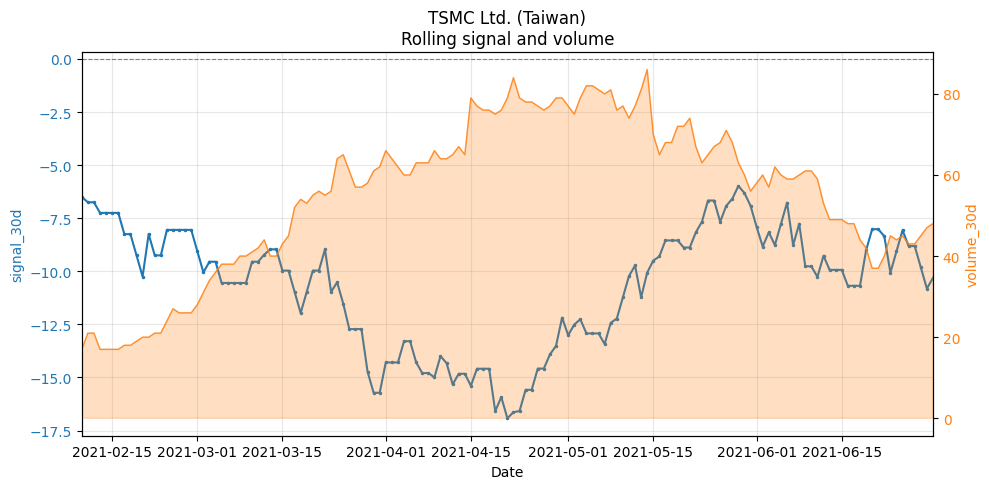

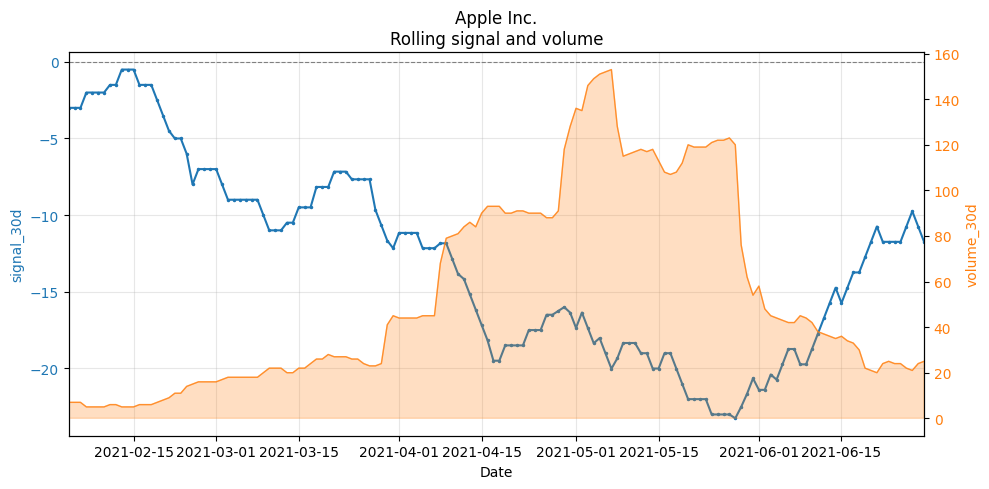

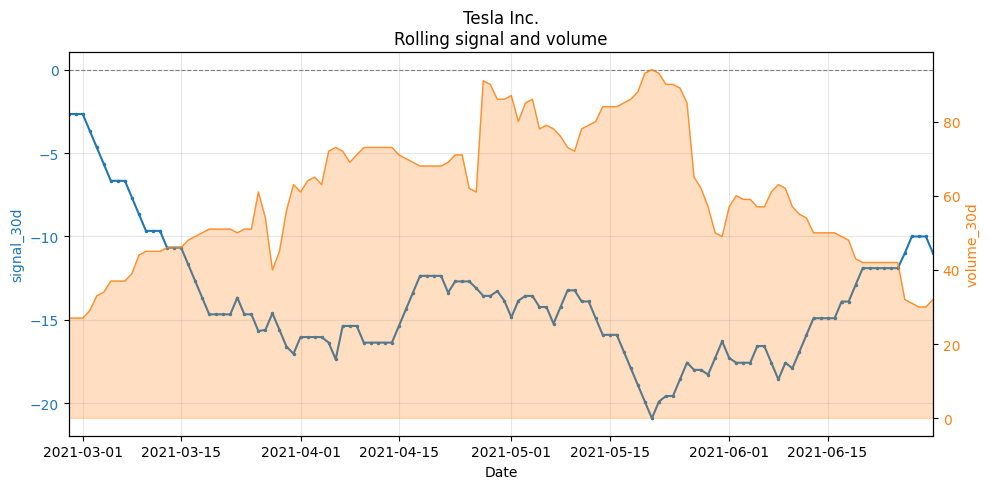

In [58]:
# Plot rolling signal for top 5 companies by volume
plot_top_entities_rolling_signal(
    df_rolling_signal,
    entity_col="entity_name",
    date_col="date_nyse_1530",
    signal_col="signal_30d",  # with the relative padding from window
    top_n=5,
)



In [59]:
# Save DF with rp_entity_id included
entity_id_map = (
    df_with_labels[["entity_name", "entity_id"]]
    .dropna(subset=["entity_name", "entity_id"])
    .drop_duplicates(subset=["entity_name"])
    .set_index("entity_name")["entity_id"]
)

df_rolling_signal_export = df_rolling_signal.copy()
if "rp_entity_id" not in df_rolling_signal_export.columns:
    df_rolling_signal_export["rp_entity_id"] = df_rolling_signal_export["entity_name"].map(entity_id_map)

# Put rp_entity_id near the entity name for easier downstream use
desired_order = ["entity_name", "rp_entity_id"] + [
    col for col in df_rolling_signal_export.columns if col not in {"entity_name", "rp_entity_id"}
]
df_rolling_signal_export = df_rolling_signal_export[desired_order]

df_rolling_signal_export.to_csv("df_rolling_signal.csv", index=False)


## Summary

You now have two complementary signal paths:

1. **Basic (relevance × sentiment):**
   - faster, broader, higher recall.
2. **Advanced (LLM-verified):**
   - stricter, higher accuracy/precision, lower recall.

For robust research practice:
- validate timing assumptions (`doc_timestamp` -> `date_nyse_1530`),
- test signal behavior across themes and market regimes,
- treat in-sample performance as a **sanity check**, not proof of persistent alpha.

Recommended next steps:
- compare basic vs advanced information ratio and turnover,
- run robustness tests across alternate themes and windows,
- evaluate implementation frictions before any live deployment.
